In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import keras
from sklearn.linear_model import LogisticRegression

In [2]:
def histogram(y_train, type):
    # Mapping from label to cancer type
    label_names = {
        0: "No Metastasis",
        1: "Bone",
        2: "Liver",
        3: "Lung",
        4: "Nervous"
    }

    # Count samples per label
    label_counts = np.bincount(y_train)
    labels = np.arange(len(label_counts))
    names = [label_names[i] for i in labels]

    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, label_counts, color='skyblue', edgecolor='black')

    # Add text annotations
    for bar, count in zip(bars, label_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 1, str(count),
                ha='center', va='bottom', fontsize=10)

    # Axis setup
    if type == 0:
        plt.title("Histogram of Y_train (before SMOTE)")
    else:
        plt.title("Histogram of Y_train (after SMOTE)")

    plt.xlabel("Cancer Type")
    plt.ylabel("Number of Patients")
    plt.xticks(labels, names, rotation=15)
    plt.ylim(0, max(label_counts) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.show()

,217092_x_at,43544_at,Characteristics..Relapse..Metastasis.Bone.
0,-0.317072,0.165847,1
1,-0.020898,0.897427,1
2,-1.068299,2.281557,0
3,-3.446621,1.950300,1
4,-2.389388,1.599062,1
...,...,...,...
640,1.463694,0.647379,1
641,0.136806,-0.052912,0
642,1.341405,-0.521103,0
643,0.169912,0.029760,0


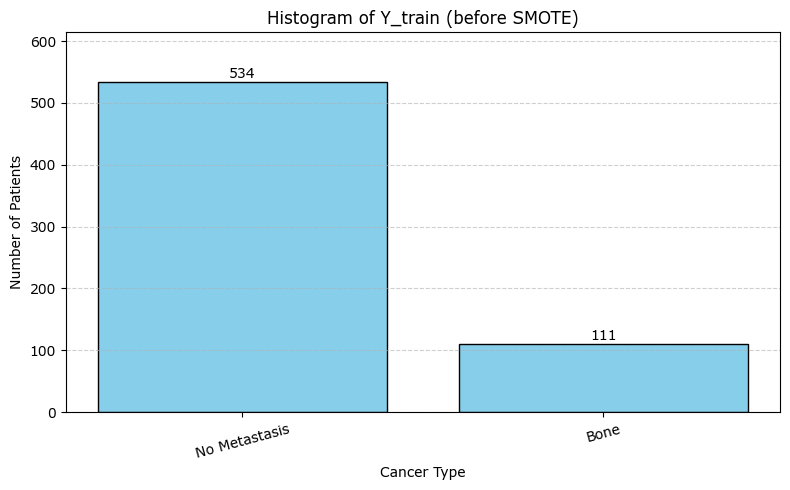

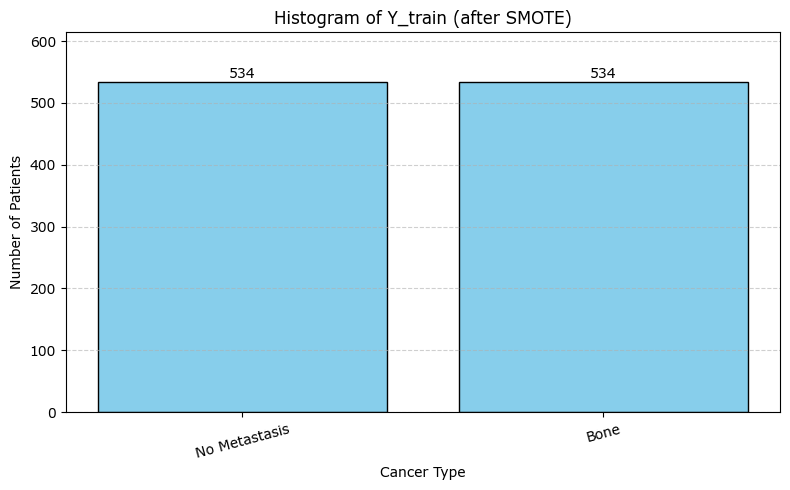

(747,)
(118,)
(203,)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load dataset
data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\New Data.csv"
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\Machine Learning Cancer - Data - Sheet1.csv"
data = pd.read_csv(data_path, delimiter=",")

# Display dataset
display(data)

# Separate features and label
X = data.iloc[:, :-1]         # All columns except the last
y = data.iloc[:, -1].astype(int)  # Convert label to integer if not already

histogram(y, 0)
smote = SMOTE(random_state=42, k_neighbors=5)
X, y = smote.fit_resample(X, y)
histogram(y, 1)

# Step 1: Split into 50% train and 50% temp with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Step 2: Split temp into 30% CV and 20% test (60/40 split of 50% temp)
X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp, y_temp, test_size=0.63, random_state=42, stratify=y_temp)

np.bincount(y_train)
print(y_train.shape)
print(y_cv.shape)
print(y_test.shape)

In [7]:
import pandas as pd
from itertools import combinations
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, accuracy_score
)

# Define gene names
gene_names = ['217092_x_at', '43544_at']

# Convert arrays to DataFrames
X_train = pd.DataFrame(X_train, columns=gene_names)
X_cv = pd.DataFrame(X_cv, columns=gene_names)
X_test = pd.DataFrame(X_test, columns=gene_names)

# Detect classification type
n_classes = len(set(y_train))

# Define models
models = {
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "NaiveBayes": GaussianNB()
}

# Store all raw results
all_results = []

# Loop through feature combinations and models
for k in range(1, len(gene_names) + 1):
    for comb in combinations(gene_names, k):
        features = list(comb)

        X_train_sel = X_train[features]
        X_cv_sel = X_cv[features]
        X_test_sel = X_test[features]

        for model_name, model in models.items():
            try:
                model.fit(X_train_sel, y_train)

                y_train_pred = model.predict(X_train_sel)
                y_cv_pred = model.predict(X_cv_sel)
                y_test_pred = model.predict(X_test_sel)

                try:
                    y_test_proba = model.predict_proba(X_test_sel)
                    if n_classes > 2:
                        auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
                    else:
                        auc = roc_auc_score(y_test, y_test_proba[:, 1])
                except:
                    auc = float('-inf')

                recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
                precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
                f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
                train_acc = accuracy_score(y_train, y_train_pred)
                cv_acc = accuracy_score(y_cv, y_cv_pred)
                test_acc = accuracy_score(y_test, y_test_pred)

                all_results.append({
                    "Model": model_name,
                    "Genes": ' + '.join(features),
                    "AUC": auc,
                    "Recall": recall,
                    "Precision": precision,
                    "F1-score": f1,
                    "Train Accuracy": train_acc,
                    "CV Accuracy": cv_acc,
                    "Test Accuracy": test_acc
                })
            except Exception as e:
                print(f"❌ Failed: {model_name} with features {features}: {e}")

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Summary selection per model
final_summary = []
metrics = {
    "Highest AUC": "AUC",
    "Highest Recall": "Recall",
    "Highest Precision": "Precision",
    "Highest F1-score": "F1-score",
    "Highest Train Accuracy": "Train Accuracy",
    "Highest CV Accuracy": "CV Accuracy",
    "Highest Test Accuracy": "Test Accuracy"
}

# For each model, extract best row per metric
for model_name in models.keys():
    model_df = results_df[results_df['Model'] == model_name]
    final_summary.append({"Model": f"=== {model_name} ==="})
    for label, metric in metrics.items():
        best_row = model_df.loc[model_df[metric].idxmax()]
        final_summary.append({
            "Metric": label,
            "Genes": best_row["Genes"],
            "AUC": best_row["AUC"],
            "Recall": best_row["Recall"],
            "Precision": best_row["Precision"],
            "F1-score": best_row["F1-score"],
            "Train Accuracy": best_row["Train Accuracy"],
            "CV Accuracy": best_row["CV Accuracy"],
            "Test Accuracy": best_row["Test Accuracy"]
        })

# Save summary
summary_df = pd.DataFrame(final_summary)
summary_df.to_csv("All_Models_Summary.csv", index=False)
print("✅ Saved grouped results to 'All_Models_Summary.csv'")


✅ Saved grouped results to 'All_Models_Summary.csv'
